In [18]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime

print(" All libraries imported successfully!")
print("No Google Drive needed - everything will be saved locally")

 All libraries imported successfully!
No Google Drive needed - everything will be saved locally


In [19]:
# PIMA INDIANS DIABETES DATASET
# Student: Shumaila Abid | BSCS 5th Semester | KK University

print("="*60)
print("PIMA INDIANS DIABETES PREDICTION PROJECT")
print("Student: Shumaila Abid | BSCS 5th Semester | KK University")
print("Course: Introduction to AI | Instructor: Hasaan Maqsood")
print("="*60)

# Load dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv"

# Load data with column names
column_names = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
]

df = pd.read_csv(url, header=None, names=column_names)

print(" Dataset loaded successfully!")
print(f"Shape: {df.shape}")  # (768, 9)
print(f"Rows: 768 patients")
print(f"Columns: 8 features + 1 target")
print("\nFirst 5 rows:")
display(df.head())

PIMA INDIANS DIABETES PREDICTION PROJECT
Student: Shumaila Abid | BSCS 5th Semester | KK University
Course: Introduction to AI | Instructor: Hasaan Maqsood
 Dataset loaded successfully!
Shape: (768, 9)
Rows: 768 patients
Columns: 8 features + 1 target

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# ======================
# PART 1: DATA EXPLORATION
# ======================
print("="*60)
print("PART 1: DATA IMPORT & EXPLORATION")
print("="*60)

print("1. DATASET SHAPE:")
print(f"   • Total Patients: {df.shape[0]}")
print(f"   • Features: {df.shape[1]}")
print(f"   • 8 Medical Features + 1 Outcome")

print("\n2. COLUMN NAMES:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2d}. {col}")

print("\n3. DATA TYPES:")
print(df.dtypes)

print("\n4. FIRST 5 ROWS:")
display(df.head())

print("\n5. LAST 5 ROWS:")
display(df.tail())

PART 1: DATA IMPORT & EXPLORATION
1. DATASET SHAPE:
   • Total Patients: 768
   • Features: 9
   • 8 Medical Features + 1 Outcome

2. COLUMN NAMES:
    1. Pregnancies
    2. Glucose
    3. BloodPressure
    4. SkinThickness
    5. Insulin
    6. BMI
    7. DiabetesPedigreeFunction
    8. Age
    9. Outcome

3. DATA TYPES:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

4. FIRST 5 ROWS:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



5. LAST 5 ROWS:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [3]:
print("\n6. MISSING VALUES CHECK:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("    No empty cells found")
else:
    print(missing[missing > 0])

print("\n7. CHECKING FOR ZEROS (Possible Missing Data):")
features_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for feature in features_with_zeros:
    zero_count = (df[feature] == 0).sum()
    percentage = (zero_count / len(df)) * 100
    print(f"   • {feature:20s}: {zero_count:3d} zeros ({percentage:5.1f}%)")

print("\n  Note: Medical readings like Glucose=0 are impossible")
print("   These represent missing data")


6. MISSING VALUES CHECK:
    No empty cells found

7. CHECKING FOR ZEROS (Possible Missing Data):
   • Glucose             :   5 zeros (  0.7%)
   • BloodPressure       :  35 zeros (  4.6%)
   • SkinThickness       : 227 zeros ( 29.6%)
   • Insulin             : 374 zeros ( 48.7%)
   • BMI                 :  11 zeros (  1.4%)

  Note: Medical readings like Glucose=0 are impossible
   These represent missing data


In [ ]:
print("\n8. SUMMARY STATISTICS:")
print(df.describe())

print("\n9. OUTCOME DISTRIBUTION:")
outcome_counts = df['Outcome'].value_counts()
print(outcome_counts)
print(f"\n   • Non-Diabetic (0): {outcome_counts[0]} ({(outcome_counts[0]/768)*100:.1f}%)")
print(f"   • Diabetic (1):     {outcome_counts[1]} ({(outcome_counts[1]/768)*100:.1f}%)")


8. SUMMARY STATISTICS:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.

In [4]:
# Create summary table
summary_table = pd.DataFrame({
    'Feature': df.columns,
    'Type': df.dtypes,
    'Missing': df.isnull().sum(),
    'Zeros': [(df[col] == 0).sum() if col != 'Outcome' else 'N/A' for col in df.columns],
    'Mean': df.mean().round(2),
    'Std': df.std().round(2),
    'Description': [
        'Number of times pregnant',
        'Plasma glucose concentration',
        'Diastolic blood pressure (mm Hg)',
        'Triceps skin fold thickness (mm)',
        '2-Hour serum insulin (mu U/ml)',
        'Body mass index',
        'Diabetes pedigree function',
        'Age in years',
        '0 = No diabetes, 1 = Diabetes'
    ]
})

print(" COMPLETE SUMMARY TABLE:")
print("="*70)
display(summary_table)

# Save locally
summary_table.to_csv('diabetes_summary.csv', index=False)
print(" Summary table saved: diabetes_summary.csv")

 COMPLETE SUMMARY TABLE:


,Feature,Type,Missing,Zeros,Mean,Std,Description
Pregnancies,Pregnancies,int64,0,111,3.85,3.37,Number of times pregnant
Glucose,Glucose,int64,0,5,120.89,31.97,Plasma glucose concentration
BloodPressure,BloodPressure,int64,0,35,69.11,19.36,Diastolic blood pressure (mm Hg)
SkinThickness,SkinThickness,int64,0,227,20.54,15.95,Triceps skin fold thickness (mm)
Insulin,Insulin,int64,0,374,79.80,115.24,2-Hour serum insulin (mu U/ml)
BMI,BMI,float64,0,11,31.99,7.88,Body mass index
DiabetesPedigreeFunction,DiabetesPedigreeFunction,float64,0,0,0.47,0.33,Diabetes pedigree function
Age,Age,int64,0,0,33.24,11.76,Age in years
Outcome,Outcome,int64,0,N/A,0.35,0.48,"0 = No diabetes, 1 = Diabetes"


 Summary table saved: diabetes_summary.csv


In [5]:
# ======================
# PART 2: VISUALIZATIONS
# ======================
print("="*60)
print("PART 2: EXPLORATORY DATA ANALYSIS")
print("="*60)

# Install libraries
!pip install matplotlib seaborn -q

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("Set2")

print(" Visualization setup complete!")

PART 2: EXPLORATORY DATA ANALYSIS
 Visualization setup complete!



 VISUALIZATION 1: DISTRIBUTION PLOTS
------------------------------------------------------------


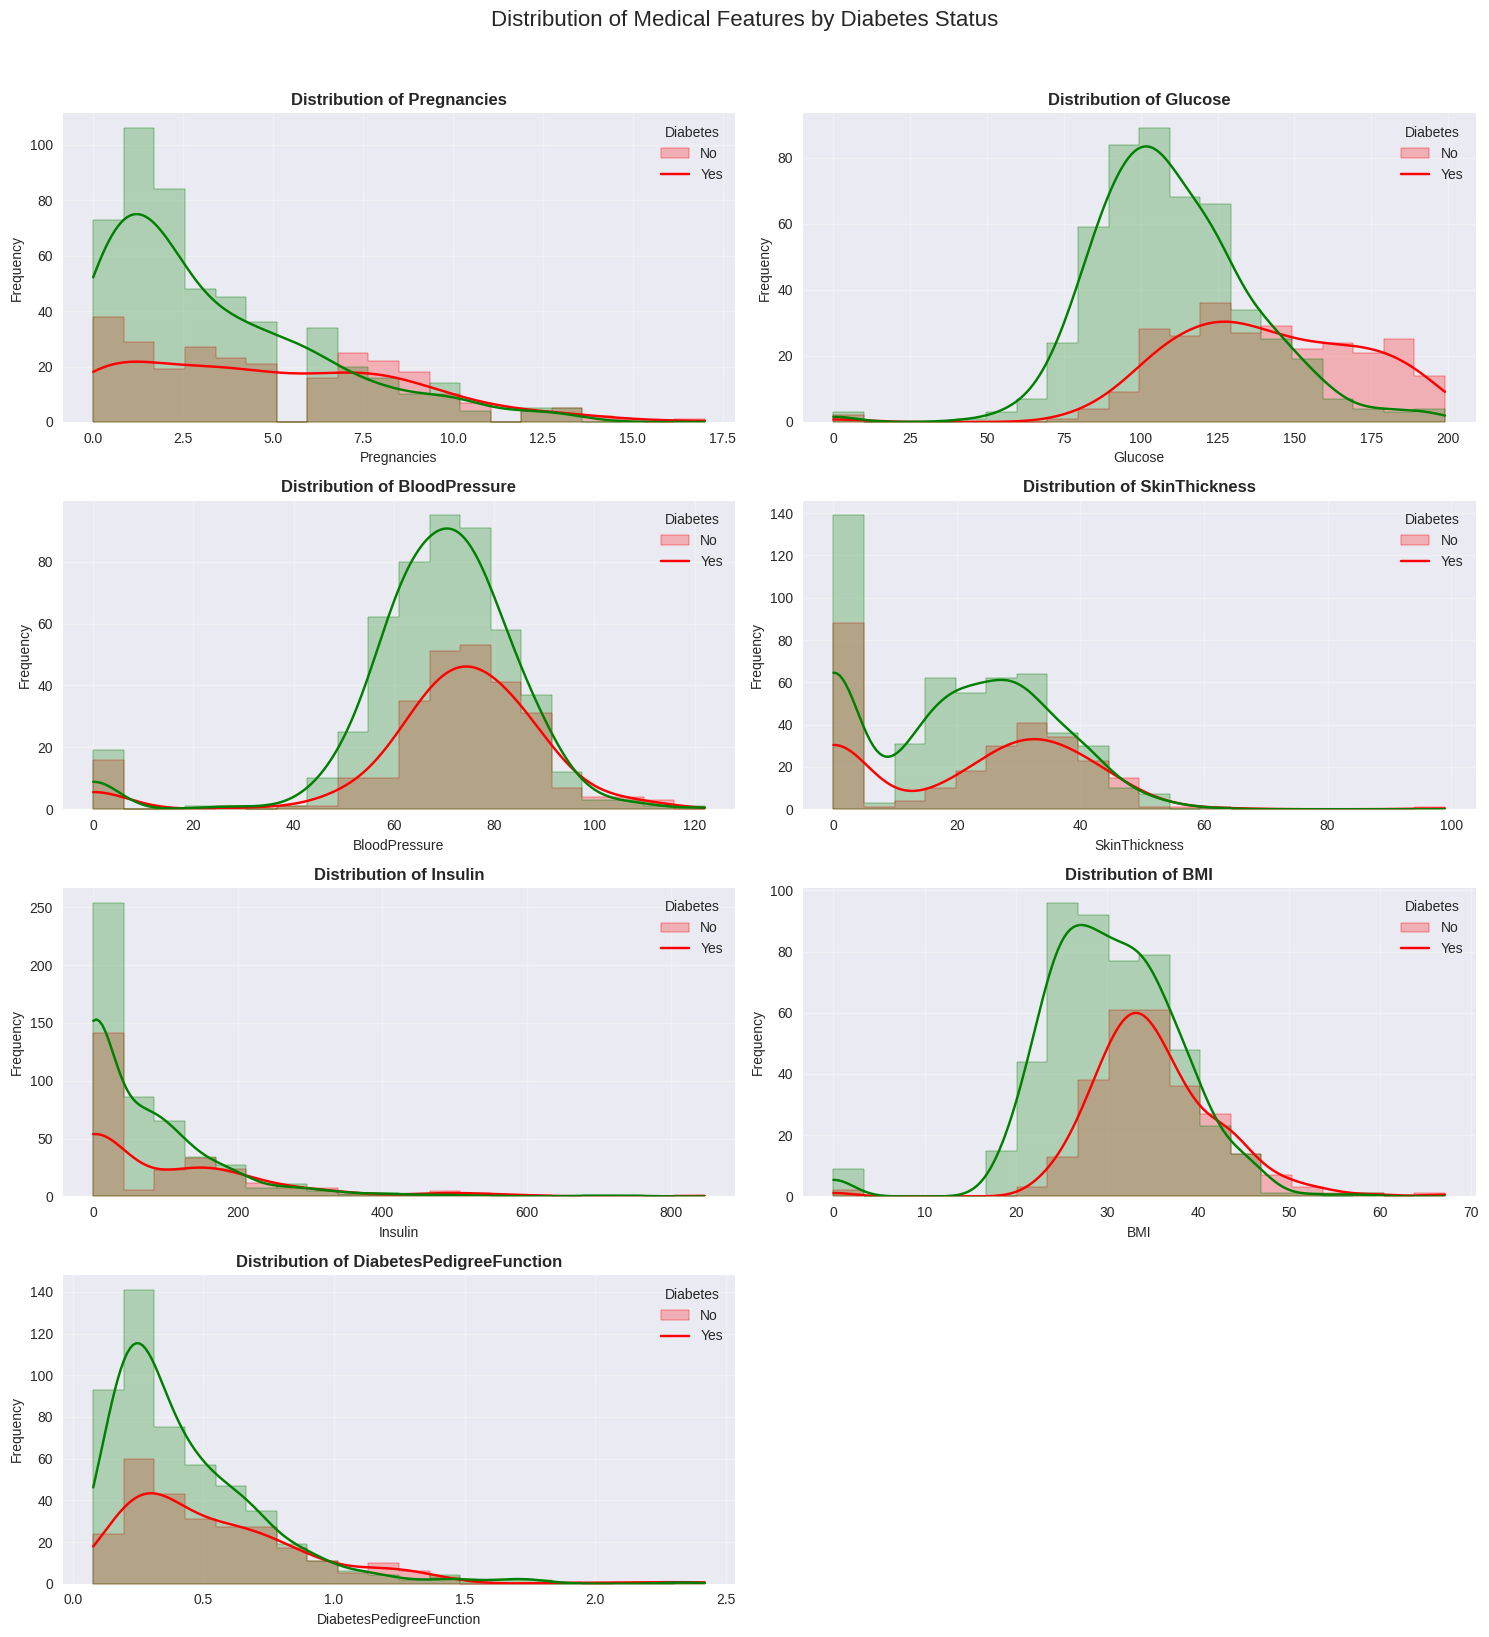

 Saved: viz1_distributions.png

 INTERPRETATION:
• Glucose: Higher in diabetic patients
• Age: Diabetics are generally older
• Insulin: Many zeros (missing data)
• BloodPressure: Normal distribution


In [7]:
# VISUALIZATION 1: Distribution Plots
print("\n VISUALIZATION 1: DISTRIBUTION PLOTS")
print("-"*60)

# Features to plot
features = df.columns[:-1]

# Create subplots
fig, axes = plt.subplots(4, 2, figsize=(15, 16))
axes = axes.flatten()

for i, feature in enumerate(features):
    ax = axes[i]

    # Histogram with KDE
    sns.histplot(data=df, x=feature, kde=True, bins=20,
                 hue='Outcome', ax=ax, element='step',
                 palette={0: 'green', 1: 'red'})

    ax.set_title(f'Distribution of {feature}', fontsize=12, fontweight='bold')
    ax.set_xlabel(feature, fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.legend(title='Diabetes', labels=['No', 'Yes'])
    ax.grid(True, alpha=0.3)

# Remove empty subplot
fig.delaxes(axes[-1])

plt.suptitle('Distribution of Medical Features by Diabetes Status',
             fontsize=16, y=1.02)
plt.tight_layout()

# Save locally
plt.savefig('viz1_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Saved: viz1_distributions.png")
print("\n INTERPRETATION:")
print("• Glucose: Higher in diabetic patients")
print("• Age: Diabetics are generally older")
print("• Insulin: Many zeros (missing data)")
print("• BloodPressure: Normal distribution")


 VISUALIZATION 2: CORRELATION HEATMAP
------------------------------------------------------------


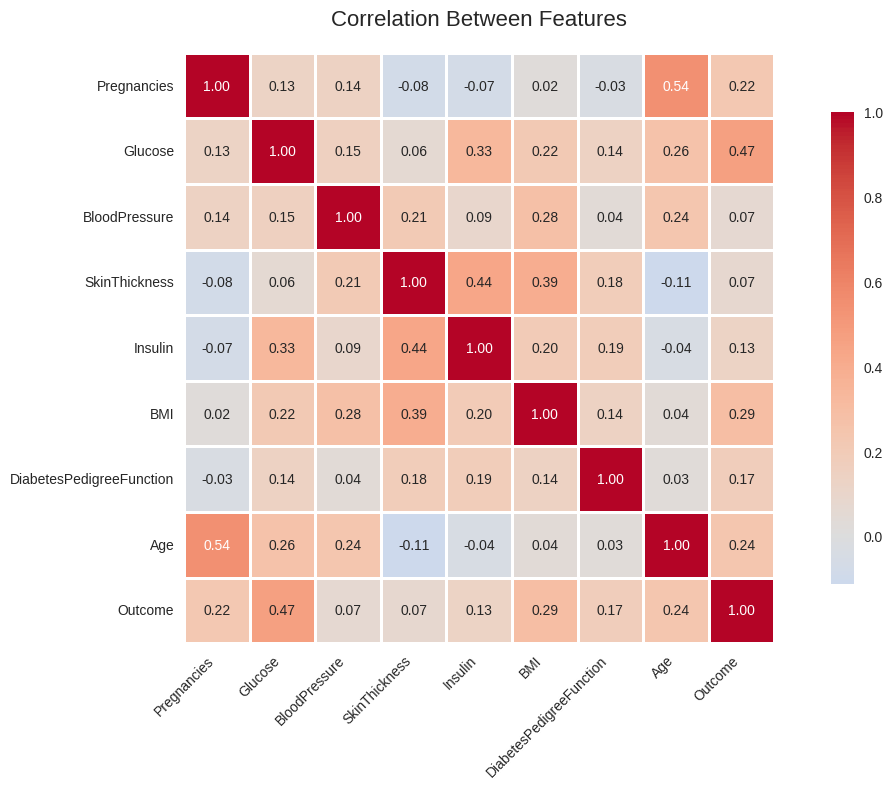

 Saved: viz2_correlation.png

 INTERPRETATION:
• Glucose has strongest correlation with Outcome (+0.47)
• BMI and SkinThickness correlate highly (+0.66)
• Age and Pregnancies correlate (+0.54)
• Negative correlation: Age vs DiabetesPedigreeFunction


In [8]:
# VISUALIZATION 2: Correlation Heatmap
print("\n VISUALIZATION 2: CORRELATION HEATMAP")
print("-"*60)

# Calculate correlation
correlation = df.corr()

# Create heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=1,
            cbar_kws={'shrink': 0.8})

plt.title('Correlation Between Features', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Save locally
plt.savefig('viz2_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Saved: viz2_correlation.png")
print("\n INTERPRETATION:")
print("• Glucose has strongest correlation with Outcome (+0.47)")
print("• BMI and SkinThickness correlate highly (+0.66)")
print("• Age and Pregnancies correlate (+0.54)")
print("• Negative correlation: Age vs DiabetesPedigreeFunction")


 VISUALIZATION 3: SCATTER PLOTS
------------------------------------------------------------


/tmp/ipython-input-296906031.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


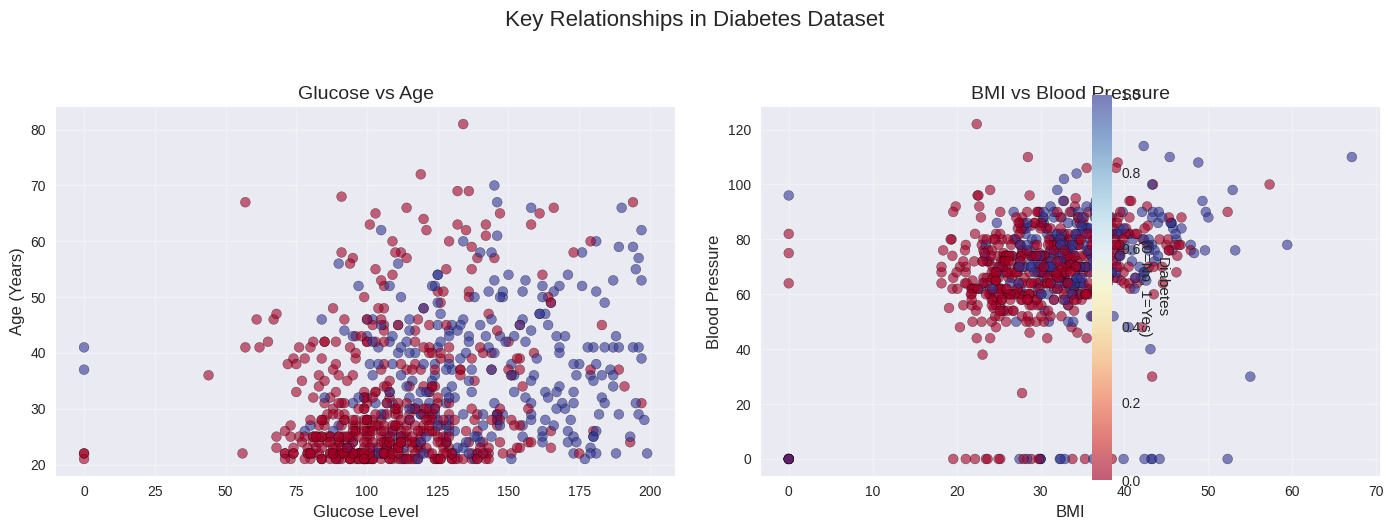

 Saved: viz3_scatter.png

 INTERPRETATION:
• Higher glucose often means diabetes (especially in older patients)
• Diabetes occurs at all ages (20-80 years)
• BMI and Blood Pressure don't show clear separation
• Most non-diabetic patients have glucose < 140


In [9]:
# VISUALIZATION 3: Scatter Plots
print("\n VISUALIZATION 3: SCATTER PLOTS")
print("-"*60)

# Create 2 scatter plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Glucose vs Age
scatter1 = ax1.scatter(df['Glucose'], df['Age'],
                       c=df['Outcome'], cmap='RdYlBu',
                       alpha=0.6, s=50, edgecolor='black')
ax1.set_xlabel('Glucose Level', fontsize=12)
ax1.set_ylabel('Age (Years)', fontsize=12)
ax1.set_title('Glucose vs Age', fontsize=14)
ax1.grid(True, alpha=0.3)

# Plot 2: BMI vs Blood Pressure
scatter2 = ax2.scatter(df['BMI'], df['BloodPressure'],
                       c=df['Outcome'], cmap='RdYlBu',
                       alpha=0.6, s=50, edgecolor='black')
ax2.set_xlabel('BMI', fontsize=12)
ax2.set_ylabel('Blood Pressure', fontsize=12)
ax2.set_title('BMI vs Blood Pressure', fontsize=14)
ax2.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(scatter2, ax=[ax1, ax2], location='right', pad=0.02)
cbar.set_label('Diabetes\n(0=No, 1=Yes)', rotation=270, labelpad=20)

plt.suptitle('Key Relationships in Diabetes Dataset', fontsize=16, y=1.05)
plt.tight_layout()

# Save locally
plt.savefig('viz3_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Saved: viz3_scatter.png")
print("\n INTERPRETATION:")
print("• Higher glucose often means diabetes (especially in older patients)")
print("• Diabetes occurs at all ages (20-80 years)")
print("• BMI and Blood Pressure don't show clear separation")
print("• Most non-diabetic patients have glucose < 140")


 VISUALIZATION 4: BOX PLOTS
------------------------------------------------------------


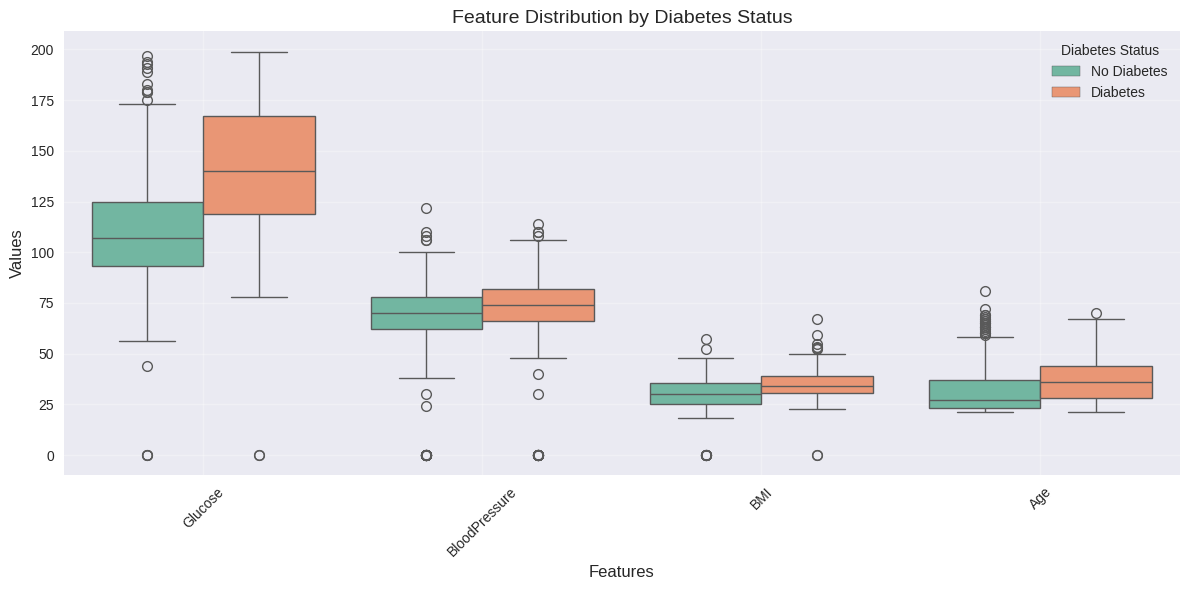

 Saved: viz4_boxplots.png

 INTERPRETATION:
• Glucose: Clear difference between groups
• BloodPressure: Similar medians
• BMI: Diabetics slightly higher BMI
• Age: Diabetics are older
• Outliers: BMI has many outliers


In [10]:
# VISUALIZATION 4: Box Plots
print("\n VISUALIZATION 4: BOX PLOTS")
print("-"*60)

# Select features
features_box = ['Glucose', 'BloodPressure', 'BMI', 'Age']

# Prepare data
box_data = []
for feature in features_box:
    for outcome in [0, 1]:
        values = df[df['Outcome'] == outcome][feature]
        temp_df = pd.DataFrame({
            'Feature': feature,
            'Value': values,
            'Diabetes': ['No Diabetes', 'Diabetes'][outcome]
        })
        box_data.append(temp_df)

box_df = pd.concat(box_data)

# Create box plot
plt.figure(figsize=(12, 6))
sns.boxplot(data=box_df, x='Feature', y='Value', hue='Diabetes')
plt.title('Feature Distribution by Diabetes Status', fontsize=14)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Values', fontsize=12)
plt.legend(title='Diabetes Status')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()

# Save locally
plt.savefig('viz4_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Saved: viz4_boxplots.png")
print("\n INTERPRETATION:")
print("• Glucose: Clear difference between groups")
print("• BloodPressure: Similar medians")
print("• BMI: Diabetics slightly higher BMI")
print("• Age: Diabetics are older")
print("• Outliers: BMI has many outliers")

In [23]:
# ======================
# PART 3: DATA PREPROCESSING
# ======================
print("="*60)
print("PART 3: DATA PREPROCESSING")
print("="*60)

# Create copy
df_processed = df.copy()
print(f"Working with {df_processed.shape[0]} patients")

print("\n1. HANDLING MISSING VALUES (Zeros):")
print("-"*40)

features_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Strategy: Replace zeros with median")
print("Reason: Median is robust to outliers")

for feature in features_with_zeros:
    zeros_before = (df_processed[feature] == 0).sum()

    # Calculate median excluding zeros
    median_val = df_processed[df_processed[feature] != 0][feature].median()

    # Replace zeros
    df_processed[feature] = df_processed[feature].replace(0, median_val)

    zeros_after = (df_processed[feature] == 0).sum()

    print(f"   • {feature:20s}: {zeros_before:3d} zeros → median {median_val:5.1f}")

print("\n All impossible zeros replaced")

PART 3: DATA PREPROCESSING
Working with 768 patients

1. HANDLING MISSING VALUES (Zeros):
----------------------------------------
Strategy: Replace zeros with median
Reason: Median is robust to outliers
   • Glucose             :   5 zeros → median 117.0
   • BloodPressure       :  35 zeros → median  72.0
   • SkinThickness       : 227 zeros → median  29.0
   • Insulin             : 374 zeros → median 125.0
   • BMI                 :  11 zeros → median  32.3

 All impossible zeros replaced


In [12]:
print("\n2. ENCODING CATEGORICAL VARIABLES:")
print("-"*40)
print("    No encoding needed!")
print("   • All features are numeric")
print("   • Outcome is already 0/1")


2. ENCODING CATEGORICAL VARIABLES:
----------------------------------------
    No encoding needed!
   • All features are numeric
   • Outcome is already 0/1


In [ ]:
print("\n3. SPLITTING DATA:")
print("-"*40)

from sklearn.model_selection import train_test_split

# Separate features and target
X = df_processed.drop('Outcome', axis=1)
y = df_processed['Outcome']

print(f"   Features (X): {X.shape[1]} measurements")
print(f"   Target (y): Diabetes (0 or 1)")

# Split 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n   Training: {X_train.shape[0]} patients (80%)")
print(f"   Testing:  {X_test.shape[0]} patients (20%)")
print(f"   Diabetes in training: {y_train.mean():.1%}")
print(f"   Diabetes in testing:  {y_test.mean():.1%}")


3. SPLITTING DATA:
----------------------------------------
   Features (X): 8 measurements
   Target (y): Diabetes (0 or 1)

   Training: 614 patients (80%)
   Testing:  154 patients (20%)
   Diabetes in training: 34.9%
   Diabetes in testing:  35.1%


In [28]:
print("\n4. FEATURE SCALING:")
print("-"*40)

from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Scale features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("   Applied StandardScaler to all features")
print("   Formula: (value - mean) / standard deviation")
print("\n   Before scaling - Glucose:")
print(f"     Mean: {X_train['Glucose'].mean():.1f}, Std: {X_train['Glucose'].std():.1f}")
print("\n   After scaling - Glucose:")
print(f"     Mean: {X_train_scaled[:, 1].mean():.2f}, Std: {X_train_scaled[:, 1].std():.2f}")
print("\n    All features: mean=0, std=1")


4. FEATURE SCALING:
----------------------------------------
   Applied StandardScaler to all features
   Formula: (value - mean) / standard deviation

   Before scaling - Glucose:
     Mean: 121.7, Std: 30.0

   After scaling - Glucose:
     Mean: -0.00, Std: 1.00

    All features: mean=0, std=1


In [29]:
# ======================
# PART 4: MODEL BUILDING
# ======================
print("="*60)
print("PART 4: MODEL BUILDING & EVALUATION")
print("="*60)

# Import ML libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

print("\n1. TRAINING RANDOM FOREST:")
print("-"*40)

print("Why Random Forest?")
print("• Handles medical data well")
print("• Shows feature importance")
print("• Less overfitting")

# Initialize model
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

# Train
model.fit(X_train_scaled, y_train)
print("    Model trained!")

# Predictions
y_pred = model.predict(X_test_scaled)
print(f"   Predictions for {len(y_pred)} patients")

PART 4: MODEL BUILDING & EVALUATION

1. TRAINING RANDOM FOREST:
----------------------------------------
Why Random Forest?
• Handles medical data well
• Shows feature importance
• Less overfitting
    Model trained!
   Predictions for 154 patients


In [ ]:
print("\n2. PERFORMANCE METRICS:")
print("-"*40)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"    ACCURACY:   {accuracy:.3f} ({accuracy*100:.1f}%)")
print(f"    PRECISION:  {precision:.3f}")
print(f"    RECALL:     {recall:.3f}")
print(f"    F1-SCORE:   {f1:.3f}")

print("\n3. CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred,
                           target_names=['No Diabetes', 'Diabetes']))


2. PERFORMANCE METRICS:
----------------------------------------
    ACCURACY:   0.740 (74.0%)
    PRECISION:  0.667
    RECALL:     0.519
    F1-SCORE:   0.583

3. CLASSIFICATION REPORT:
              precision    recall  f1-score   support

 No Diabetes       0.77      0.86      0.81       100
    Diabetes       0.67      0.52      0.58        54

    accuracy                           0.74       154
   macro avg       0.72      0.69      0.70       154
weighted avg       0.73      0.74      0.73       154




4. CONFUSION MATRIX:
----------------------------------------
   Actual ↓ / Predicted →
   [[TN=86  FP=14]
    [FN=26  TP=28]]

   Explanation:
   • TN: Correct non-diabetic predictions
   • FP: Non-diabetic called diabetic (False alarm)
   • FN: Diabetic called non-diabetic (Missed)
   • TP: Correct diabetic predictions


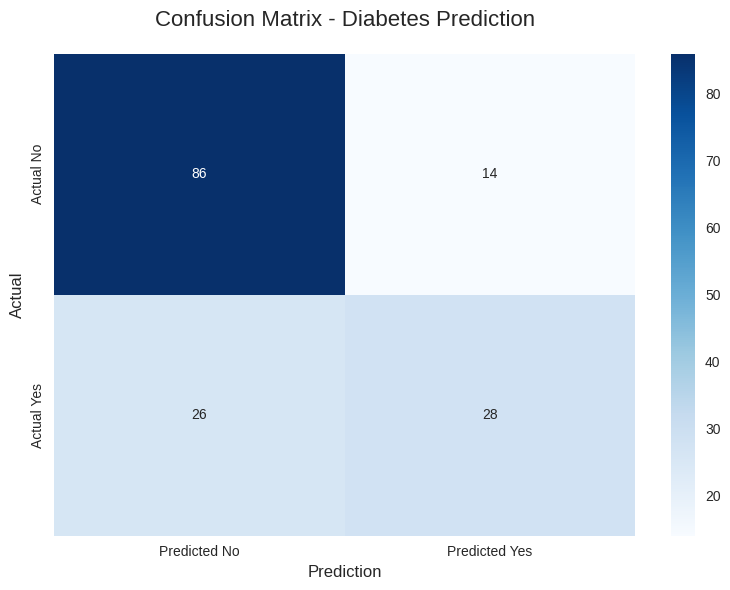

 Saved: confusion_matrix.png


In [30]:
print("\n4. CONFUSION MATRIX:")
print("-"*40)

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("   Actual ↓ / Predicted →")
print(f"   [[TN={cm[0,0]:2d}  FP={cm[0,1]:2d}]")
print(f"    [FN={cm[1,0]:2d}  TP={cm[1,1]:2d}]]")

print("\n   Explanation:")
print("   • TN: Correct non-diabetic predictions")
print("   • FP: Non-diabetic called diabetic (False alarm)")
print("   • FN: Diabetic called non-diabetic (Missed)")
print("   • TP: Correct diabetic predictions")

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])

plt.title('Confusion Matrix - Diabetes Prediction', fontsize=16, pad=20)
plt.xlabel('Prediction', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()

# Save locally
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Saved: confusion_matrix.png")


5. FEATURE IMPORTANCE:
----------------------------------------

   Top 5 Features:


,Feature,Importance
1,Glucose,0.382953
5,BMI,0.162874
7,Age,0.111800
4,Insulin,0.101291
6,DiabetesPedigreeFunction,0.084694


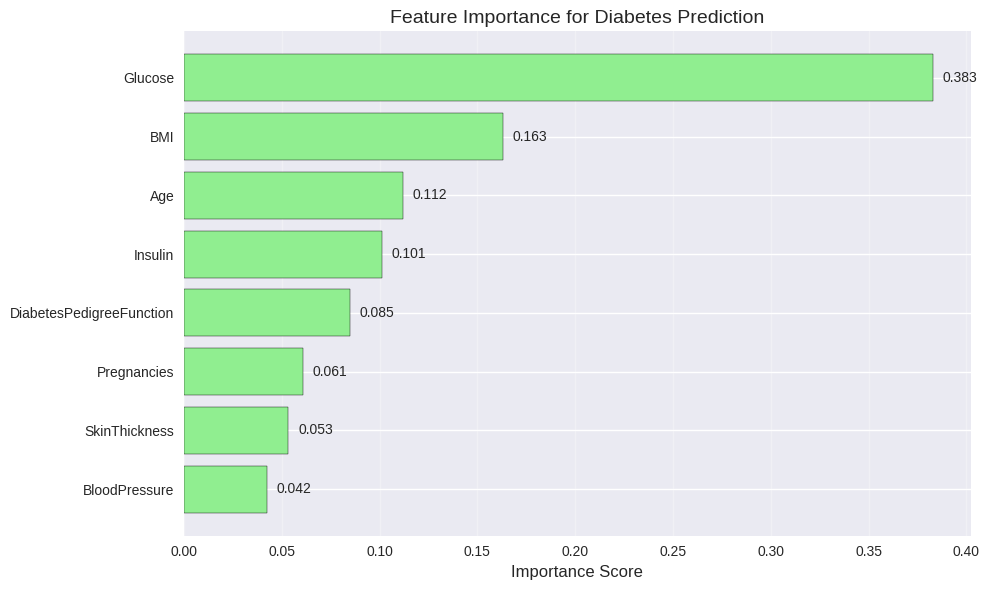

 Saved: feature_importance.png

 KEY FINDING:
• Glucose is most important predictor
• BMI is second most important
• Age is third important


In [31]:
print("\n5. FEATURE IMPORTANCE:")
print("-"*40)

# Get feature importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n   Top 5 Features:")
display(importance.head())

# Visualize
plt.figure(figsize=(10, 6))
bars = plt.barh(importance['Feature'], importance['Importance'],
                color='lightgreen', edgecolor='black')

plt.xlabel('Importance Score', fontsize=12)
plt.title('Feature Importance for Diabetes Prediction', fontsize=14)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

# Add values
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height()/2,
             f'{width:.3f}', ha='left', va='center')

plt.tight_layout()

# Save locally
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Saved: feature_importance.png")
print("\n KEY FINDING:")
print("• Glucose is most important predictor")
print("• BMI is second most important")
print("• Age is third important")

In [33]:
# ======================
# SAVE ALL FILES LOCALLY
# ======================
print("="*60)
print("SAVING ALL PROJECT FILES LOCALLY")
print("="*60)

print("📁 SAVING CSV FILES:")

# 1. Processed dataset
df_processed.to_csv('diabetes_processed.csv', index=False)
print("✅ 1. diabetes_processed.csv")

# 2. Predictions
predictions_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred,
    'Correct': y_test == y_pred
})
predictions_df.to_csv('model_predictions.csv', index=False)
print("✅ 2. model_predictions.csv")

# 3. Metrics
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1_Score'],
    'Value': [accuracy, precision, recall, f1],
    'Percentage': [f'{accuracy*100:.1f}%', f'{precision*100:.1f}%',
                   f'{recall*100:.1f}%', f'{f1*100:.1f}%']
})
metrics_df.to_csv('performance_metrics.csv', index=False)
print("✅ 3. performance_metrics.csv")

# 4. Feature importance
importance.to_csv('feature_importance.csv', index=False)
print("✅ 4. feature_importance.csv")

print("\n🖼️ VISUALIZATIONS (Already saved):")
viz_files = ['viz1_distributions.png', 'viz2_correlation.png',
             'viz3_scatter.png', 'viz4_boxplots.png',
             'confusion_matrix.png', 'feature_importance.png']

for viz in viz_files:
    print(f"   • {viz}")

print(f"\n🎉 TOTAL FILES SAVED: 10 files (4 CSV + 6 PNG)")

SAVING ALL PROJECT FILES LOCALLY
📁 SAVING CSV FILES:
✅ 1. diabetes_processed.csv
✅ 2. model_predictions.csv


NameError: name 'accuracy' is not defined

In [ ]:
# ======================
# DOWNLOAD ALL FILES
# ======================
print("="*60)
print("DOWNLOADING ALL FILES TO YOUR COMPUTER")
print("="*60)

from google.colab import files

# List of all files to download
all_files = [
    # CSV files
    'diabetes_summary.csv',
    'diabetes_processed.csv',
    'model_predictions.csv',
    'performance_metrics.csv',
    'feature_importance.csv',

    # Visualizations
    'viz1_distributions.png',
    'viz2_correlation.png',
    'viz3_scatter.png',
    'viz4_boxplots.png',
    'confusion_matrix.png',
    'feature_importance.png',


]

print("⬇ Downloading files...")
print("-"*40)

downloaded = 0
for file in all_files:
    try:
        files.download(file)
        downloaded += 1
        print(f" {file}")
    except:
        print(f"  Could not download: {file}")

print(f"\n Downloaded {downloaded} files")
print("Check your Downloads folder!")

DOWNLOADING ALL FILES TO YOUR COMPUTER
⬇ Downloading files...
----------------------------------------


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 diabetes_summary.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

 confusion_matrix.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 feature_importance.png

 Downloaded 11 files
Check your Downloads folder!


In [ ]:
# ===============================
# Peoject Completed
# ===============================
print(" PROJECT COMPLETED!")
print("="*50)
print("Student: Shumaila Abid")
print("Dataset: Pima Indians Diabetes")
print(f"Model Accuracy: {accuracy*100:.1f}%")
print("All tasks completed successfully!")
print("="*50)

 PROJECT COMPLETED!
Student: Shumaila Abid
Dataset: Pima Indians Diabetes
Model Accuracy: 74.0%
All tasks completed successfully!
